In [ ]:
!pip install feedparser

In [ ]:
from google.colab import drive
import feedparser
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define Google News RSS feed for "Ammonia Market"
rss_url = "https://news.google.com/rss/search?q=naturalgas+market"

# Parse RSS feed
news_feed = feedparser.parse(rss_url)

# Extract headlines and links
data = []
for entry in news_feed.entries:
    data.append({"Headline": entry.title, "URL": entry.link})

# Convert to DataFrame
df_news = pd.DataFrame(data)

# Save to Google Drive
csv_path = "/content/drive/My Drive/naturalgas_news.csv"
df_news.to_csv(csv_path, index=False)

print(f"CSV saved at: {csv_path}")
print(df_news.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV saved at: /content/drive/My Drive/naturalgas_news.csv
                                            Headline  \
0  Natural Gas Weekly Update - U.S. Energy Inform...   
1  How Eastern Europe Overhauled Its Natural Gas ...   
2  No, LNG Exports Won’t Increase U.S. Gas Prices...   
3  EU Discusses Targeting of Spot Market for Russ...   
4  Natural Gas Price Outlook – Natural Gas Attemp...   

                                                 URL  
0  https://news.google.com/rss/articles/CBMiT0FVX...  
1  https://news.google.com/rss/articles/CBMiqwFBV...  
2  https://news.google.com/rss/articles/CBMiqgFBV...  
3  https://news.google.com/rss/articles/CBMitAFBV...  
4  https://news.google.com/rss/articles/CBMivgFBV...  


In [ ]:
df_news

,Headline,URL
0,Natural Gas Weekly Update - U.S. Energy Inform...,https://news.google.com/rss/articles/CBMiT0FVX...
1,How Eastern Europe Overhauled Its Natural Gas ...,https://news.google.com/rss/articles/CBMiqwFBV...
2,"No, LNG Exports Won’t Increase U.S. Gas Prices...",https://news.google.com/rss/articles/CBMiqgFBV...
3,EU Discusses Targeting of Spot Market for Russ...,https://news.google.com/rss/articles/CBMitAFBV...
4,Natural Gas Price Outlook – Natural Gas Attemp...,https://news.google.com/rss/articles/CBMivgFBV...
...,...,...
95,Spring is Here—And in the Natural Gas Market -...,https://news.google.com/rss/articles/CBMi5AFBV...
96,The LNG Market Will Remain Tight Until 2027 - ...,https://news.google.com/rss/articles/CBMitgFBV...
97,Natural Gas News: Is the First Storage Build a...,https://news.google.com/rss/articles/CBMi1wFBV...
98,Best Natural Gas Stocks for 2025 - The Motley ...,https://news.google.com/rss/articles/CBMijgFBV...


Adding the Date column

In [ ]:
from google.colab import drive
import feedparser
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define Google News RSS feed for "Natural Gas Market"
rss_url = "https://news.google.com/rss/search?q=naturalgas+market"

# Parse RSS feed
news_feed = feedparser.parse(rss_url)

# Extract headlines, URLs, and dates
data = []
for entry in news_feed.entries:
    data.append({
        "Headline": entry.title,
        "URL": entry.link,
        "Date": pd.to_datetime(entry.published, errors='coerce').date()  # Extract and format date
    })

# Convert to DataFrame
df_news = pd.DataFrame(data)

# Save to Google Drive
csv_path = "/content/drive/My Drive/naturalgas_news_with_dates.csv"
df_news.to_csv(csv_path, index=False)

print(f"CSV saved at: {csv_path}")
print(df_news.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV saved at: /content/drive/My Drive/naturalgas_news_with_dates.csv
                                            Headline  \
0  Natural Gas Weekly Update - U.S. Energy Inform...   
1  How Eastern Europe Overhauled Its Natural Gas ...   
2  No, LNG Exports Won’t Increase U.S. Gas Prices...   
3  EU Discusses Targeting of Spot Market for Russ...   
4  Natural Gas Price Outlook – Natural Gas Attemp...   

                                                 URL        Date  
0  https://news.google.com/rss/articles/CBMiT0FVX...  2025-04-17  
1  https://news.google.com/rss/articles/CBMiqwFBV...  2025-04-22  
2  https://news.google.com/rss/articles/CBMiqgFBV...  2025-04-22  
3  https://news.google.com/rss/articles/CBMitAFBV...  2025-04-23  
4  https://news.google.com/rss/articles/CBMivgFBV...  2025-04-22  


In [ ]:
df_news

,Headline,URL,Date
0,Natural Gas Weekly Update - U.S. Energy Inform...,https://news.google.com/rss/articles/CBMiT0FVX...,2025-04-17
1,How Eastern Europe Overhauled Its Natural Gas ...,https://news.google.com/rss/articles/CBMiqwFBV...,2025-04-22
2,"No, LNG Exports Won’t Increase U.S. Gas Prices...",https://news.google.com/rss/articles/CBMiqgFBV...,2025-04-22
3,EU Discusses Targeting of Spot Market for Russ...,https://news.google.com/rss/articles/CBMitAFBV...,2025-04-23
4,Natural Gas Price Outlook – Natural Gas Attemp...,https://news.google.com/rss/articles/CBMivgFBV...,2025-04-22
...,...,...,...
95,Spring is Here—And in the Natural Gas Market -...,https://news.google.com/rss/articles/CBMi5AFBV...,2025-03-20
96,The LNG Market Will Remain Tight Until 2027 - ...,https://news.google.com/rss/articles/CBMitgFBV...,2024-10-30
97,Natural Gas News: Is the First Storage Build a...,https://news.google.com/rss/articles/CBMi1wFBV...,2025-03-22
98,Best Natural Gas Stocks for 2025 - The Motley ...,https://news.google.com/rss/articles/CBMijgFBV...,2025-01-13


Assigning Sentiments

In [ ]:
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (if not already installed)
nltk.download('vader_lexicon')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Function to get sentiment scores
def get_sentiment(text):
    score = sia.polarity_scores(text)  # Get VADER sentiment scores
    return score['compound']  # Compound score is the most informative

# Apply sentiment analysis to headlines
df_news["Sentiment_Score"] = df_news["Headline"].apply(get_sentiment)

# Save updated CSV to Google Drive
csv_path_sentiment = "/content/drive/My Drive/naturalgas_news_sentiment.csv"
df_news.to_csv(csv_path_sentiment, index=False)

print(f"Sentiment analysis completed. CSV saved at: {csv_path_sentiment}")
print(df_news.head())


Sentiment analysis completed. CSV saved at: /content/drive/My Drive/naturalgas_news_sentiment.csv
                                            Headline  \
0  Natural Gas Weekly Update - U.S. Energy Inform...   
1  How Eastern Europe Overhauled Its Natural Gas ...   
2  No, LNG Exports Won’t Increase U.S. Gas Prices...   
3  EU Discusses Targeting of Spot Market for Russ...   
4  Natural Gas Price Outlook – Natural Gas Attemp...   

                                                 URL        Date  \
0  https://news.google.com/rss/articles/CBMiT0FVX...  2025-04-17   
1  https://news.google.com/rss/articles/CBMiqwFBV...  2025-04-22   
2  https://news.google.com/rss/articles/CBMiqgFBV...  2025-04-22   
3  https://news.google.com/rss/articles/CBMitAFBV...  2025-04-23   
4  https://news.google.com/rss/articles/CBMivgFBV...  2025-04-22   

   Sentiment_Score  
0           0.5574  
1           0.7184  
2           0.2960  
3           0.0000  
4           0.6124  


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
df_news

,Headline,URL,Date,Sentiment_Score
0,Natural Gas Weekly Update - U.S. Energy Inform...,https://news.google.com/rss/articles/CBMiT0FVX...,2025-04-17,0.5574
1,How Eastern Europe Overhauled Its Natural Gas ...,https://news.google.com/rss/articles/CBMiqwFBV...,2025-04-22,0.7184
2,"No, LNG Exports Won’t Increase U.S. Gas Prices...",https://news.google.com/rss/articles/CBMiqgFBV...,2025-04-22,0.2960
3,EU Discusses Targeting of Spot Market for Russ...,https://news.google.com/rss/articles/CBMitAFBV...,2025-04-23,0.0000
4,Natural Gas Price Outlook – Natural Gas Attemp...,https://news.google.com/rss/articles/CBMivgFBV...,2025-04-22,0.6124
...,...,...,...,...
95,Spring is Here—And in the Natural Gas Market -...,https://news.google.com/rss/articles/CBMi5AFBV...,2025-03-20,0.3612
96,The LNG Market Will Remain Tight Until 2027 - ...,https://news.google.com/rss/articles/CBMitgFBV...,2024-10-30,0.0000
97,Natural Gas News: Is the First Storage Build a...,https://news.google.com/rss/articles/CBMi1wFBV...,2025-03-22,0.0772
98,Best Natural Gas Stocks for 2025 - The Motley ...,https://news.google.com/rss/articles/CBMijgFBV...,2025-01-13,0.5859


Adding the pricing data

In [ ]:
import yfinance as yf

In [ ]:
import pandas as pd
import yfinance as yf

# Define stock ticker
stock_ticker = "NG=F"

# Ensure 'Date' is in datetime format
df_news["Date"] = pd.to_datetime(df_news["Date"])

# Get full date range (first to last article date)
start_date = df_news["Date"].min()
end_date = df_news["Date"].max()

# Download full stock data for the date range
df_stock = yf.download(stock_ticker, start=start_date, end=end_date + pd.Timedelta(days=1))

# Keep only closing prices
df_stock = df_stock["Close"].reset_index()
df_stock.columns = ["Date", "Close"]

# Convert date format to match df_news
df_stock["Date"] = df_stock["Date"].dt.date
df_news["Date"] = df_news["Date"].dt.date

# Merge stock prices with news data
df_merged = pd.merge(df_stock, df_news, on="Date", how="left")

# Carry forward missing values (for all relevant columns)
df_merged[["Headline", "Sentiment_Score", "URL"]] = df_merged[["Headline", "Sentiment_Score", "URL"]].fillna(method="ffill")

# Save final merged data
csv_path_final = "/content/drive/My Drive/naturalgas_news_stock_prices.csv"
df_merged.to_csv(csv_path_final, index=False)

# Print confirmation & preview data
print(f"Merged data saved at: {csv_path_final}")
print(df_merged.head(20))  # Display first 20 rows for verification


[*********************100%***********************]  1 of 1 completed

Merged data saved at: /content/drive/My Drive/naturalgas_news_stock_prices.csv
          Date  Close                                           Headline  \
0   2024-07-29  1.907  What is the natural gas futures market? - U.S....   
1   2024-07-30  2.126  What is the natural gas futures market? - U.S....   
2   2024-07-31  2.036  What is the natural gas futures market? - U.S....   
3   2024-08-01  1.968  What is the natural gas futures market? - U.S....   
4   2024-08-02  1.967  What is the natural gas futures market? - U.S....   
5   2024-08-05  1.942  What is the natural gas futures market? - U.S....   
6   2024-08-06  2.010  What is the natural gas futures market? - U.S....   
7   2024-08-07  2.112  US natural gas producers eye more output cuts ...   
8   2024-08-08  2.127  US natural gas producers eye more output cuts ...   
9   2024-08-09  2.143  US natural gas producers eye more output cuts ...   
10  2024-08-12  2.189  US natural gas producers eye more output cuts ...   
11  2024-


<ipython-input-48-e98648594ee8>:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_merged[["Headline", "Sentiment_Score", "URL"]] = df_merged[["Headline", "Sentiment_Score", "URL"]].fillna(method="ffill")


In [ ]:
df_merged

,Date,Close,Headline,URL,Sentiment_Score
0,2024-07-29,1.907,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574
1,2024-07-30,2.126,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574
2,2024-07-31,2.036,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574
3,2024-08-01,1.968,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574
4,2024-08-02,1.967,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574
...,...,...,...,...,...
213,2025-04-22,3.007,European Gas Prices Ease as Storage Injections...,https://news.google.com/rss/articles/CBMiqgFBV...,0.6486
214,2025-04-22,3.007,Natural Gas and Oil Forecast: Triangle Breakou...,https://news.google.com/rss/articles/CBMi1gFBV...,-0.2263
215,2025-04-22,3.007,"Spot market natural gas prices for Monday, Apr...",https://news.google.com/rss/articles/CBMiogFBV...,0.3612
216,2025-04-23,3.022,EU Discusses Targeting of Spot Market for Russ...,https://news.google.com/rss/articles/CBMitAFBV...,0.0000


Adding the moving averages

In [ ]:
# Step 1: Ensure pandas is imported
import pandas as pd

# Step 2: Define moving average window sizes
short_window = 10  # Short-term moving average (SMA)
long_window = 50   # Long-term moving average (LMA)

# Step 3: Convert 'Close' column to numeric (in case of any non-numeric values)
df_merged['Close'] = pd.to_numeric(df_merged['Close'], errors='coerce')

# Step 4: Compute the moving averages
df_merged['SMA_10'] = df_merged['Close'].rolling(window=short_window, min_periods=1).mean()
df_merged['LMA_50'] = df_merged['Close'].rolling(window=long_window, min_periods=1).mean()

# Step 5: Define function to classify trend
def classify_trend(sma, lma):
    if sma > lma:
        return "Bullish"
    elif sma < lma:
        return "Bearish"
    else:
        return "Neutral"

# Step 6: Apply the function to create 'Trend' column
df_merged['Trend'] = df_merged.apply(lambda row: classify_trend(row['SMA_10'], row['LMA_50']), axis=1)

# Step 7: Display the updated DataFrame
df_merged.head()


,Date,Close,Headline,URL,Sentiment_Score,SMA_10,LMA_50,Trend
0,2024-07-29,1.907,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574,1.90700,1.90700,Neutral
1,2024-07-30,2.126,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574,2.01650,2.01650,Neutral
2,2024-07-31,2.036,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574,2.02300,2.02300,Neutral
3,2024-08-01,1.968,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574,2.00925,2.00925,Neutral
4,2024-08-02,1.967,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,0.5574,2.00080,2.00080,Neutral


In [ ]:
print(df_merged.columns)  # Check available columns


Index(['Date', 'Close', 'Headline', 'URL', 'Sentiment_Score', 'SMA_10',
       'LMA_50', 'Trend'],
      dtype='object')


Encoding and Mapping

In [ ]:
# Step 4: Create df_encoded (copy df_merged, remove 'URL', encode 'Headline' and 'Trend')
df_encoded = df_merged.copy()
df_encoded.drop(columns=['URL'], inplace=True)

# Encode 'Headline' column
headline_mapping = {headline: idx for idx, headline in enumerate(df_encoded['Headline'].unique())}
df_encoded['Headline'] = df_encoded['Headline'].map(headline_mapping)

# Encode 'Trend' column
trend_mapping = {trend: idx for idx, trend in enumerate(df_encoded['Trend'].unique())}
df_encoded['Trend'] = df_encoded['Trend'].map(trend_mapping)

# Step 5: Create df_mapping to store both headline and trend mappings
df_mapping_headline = pd.DataFrame(list(headline_mapping.items()), columns=['Original_Headline', 'Encoded_Headline'])
df_mapping_trend = pd.DataFrame(list(trend_mapping.items()), columns=['Original_Trend', 'Encoded_Trend'])

# Concatenate both mappings into a single reference DataFrame
df_mapping = pd.concat([df_mapping_headline, df_mapping_trend], axis=1)

# Step 6: Define file paths in Google Drive
encoded_file_path = "/content/drive/MyDrive/df_encoded.csv"
mapping_file_path = "/content/drive/MyDrive/df_mapping.csv"

# Step 7: Save the DataFrames as CSV files
df_encoded.to_csv(encoded_file_path, index=False)
df_mapping.to_csv(mapping_file_path, index=False)

print(f"Files saved successfully:\n{encoded_file_path}\n{mapping_file_path}")



Files saved successfully:
/content/drive/MyDrive/df_encoded.csv
/content/drive/MyDrive/df_mapping.csv


In [ ]:
df_encoded

,Date,Close,Headline,Sentiment_Score,SMA_10,LMA_50,Trend
0,2024-07-29,1.907,0,0.5574,1.90700,1.90700,0
1,2024-07-30,2.126,0,0.5574,2.01650,2.01650,0
2,2024-07-31,2.036,0,0.5574,2.02300,2.02300,0
3,2024-08-01,1.968,0,0.5574,2.00925,2.00925,0
4,2024-08-02,1.967,0,0.5574,2.00080,2.00080,0
...,...,...,...,...,...,...,...
213,2025-04-22,3.007,87,0.6486,3.01060,3.59276,2
214,2025-04-22,3.007,88,-0.2263,3.00970,3.57122,2
215,2025-04-22,3.007,89,0.3612,3.00880,3.54914,2
216,2025-04-23,3.022,90,0.0000,3.00940,3.52750,2


In [ ]:
df_mapping

,Original_Headline,Encoded_Headline,Original_Trend,Encoded_Trend
0,What is the natural gas futures market? - U.S....,0,Neutral,0.0
1,US natural gas producers eye more output cuts ...,1,Bullish,1.0
2,Southern California natural gas market's unusu...,2,Bearish,2.0
3,"Natural Gas Market Indicators – August 29, 202...",3,NaN,NaN
4,US natural gas markets point to steep price ri...,4,NaN,NaN
...,...,...,...,...
87,European Gas Prices Ease as Storage Injections...,87,NaN,NaN
88,Natural Gas and Oil Forecast: Triangle Breakou...,88,NaN,NaN
89,"Spot market natural gas prices for Monday, Apr...",89,NaN,NaN
90,EU Discusses Targeting of Spot Market for Russ...,90,NaN,NaN


Price and Sentiment Trends

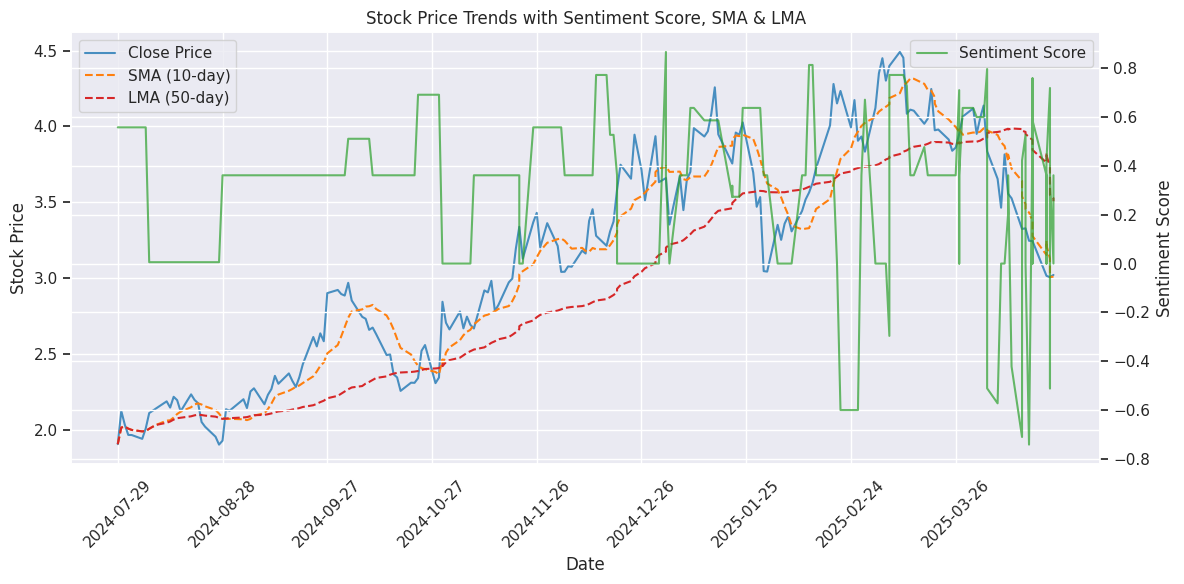

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set seaborn theme
sns.set_theme(style="darkgrid")

# Ensure Date column is in datetime format
df_encoded['Date'] = pd.to_datetime(df_encoded['Date'])

# Sort values by Date
df_encoded = df_encoded.sort_values(by='Date')

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot smoothed Close Price
ax1.plot(df_encoded['Date'], df_encoded['Close'], label='Close Price', color='tab:blue', alpha=0.8)
ax1.plot(df_encoded['Date'], df_encoded['SMA_10'], label='SMA (10-day)', color='tab:orange', linestyle='dashed')
ax1.plot(df_encoded['Date'], df_encoded['LMA_50'], label='LMA (50-day)', color='tab:red', linestyle='dashed')

# Set x-axis ticks at equal intervals (e.g., every 7 days)
date_range = pd.date_range(start=df_encoded['Date'].min(), end=df_encoded['Date'].max(), freq='30D')
ax1.set_xticks(date_range)
ax1.set_xticklabels(date_range.strftime('%Y-%m-%d'), rotation=45)

ax1.set_xlabel('Date')
ax1.set_ylabel('Stock Price')
ax1.legend(loc='upper left')

# Create second y-axis for Sentiment Score
ax2 = ax1.twinx()
ax2.plot(df_encoded['Date'], df_encoded['Sentiment_Score'], label='Sentiment Score', color='tab:green', alpha=0.7)
ax2.set_ylabel('Sentiment Score')
ax2.legend(loc='upper right')

# Set title
plt.title("Stock Price Trends with Sentiment Score, SMA & LMA")

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


Trend Distribution Analysis

<ipython-input-56-512fa24411f2>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trend_counts.index, y=trend_counts.values, palette="pastel")


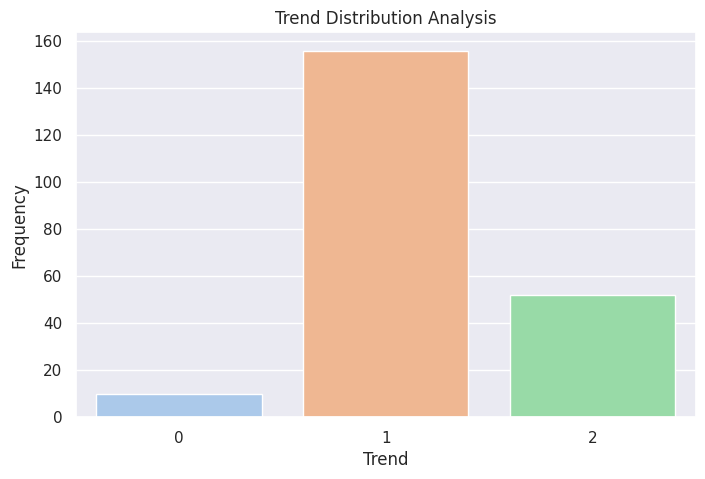

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the frequency of each trend
trend_counts = df_encoded['Trend'].value_counts()

# Plot bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=trend_counts.index, y=trend_counts.values, palette="pastel")

# Labels and title
plt.xlabel("Trend")
plt.ylabel("Frequency")
plt.title("Trend Distribution Analysis")
plt.show()


Anomaly Detection

In [ ]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest on Close Price
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df_encoded["Anomaly"] = iso_forest.fit_predict(df_encoded[["Close"]])

# Separate anomalies for analysis
anomalies = df_encoded[df_encoded["Anomaly"] == -1].copy()  # Copy to avoid SettingWithCopyWarning

# Display detected anomalies
print(anomalies[["Date", "Close", "Sentiment_Score", "Trend", "Anomaly"]])



          Date  Close  Sentiment_Score  Trend  Anomaly
0   2024-07-29  1.907           0.5574      0       -1
5   2024-08-05  1.942           0.5574      0       -1
18  2024-08-22  2.053           0.0056      1       -1
21  2024-08-27  1.904           0.0056      1       -1
22  2024-08-28  1.930           0.3612      1       -1
157 2025-03-04  4.350           0.0000      1       -1
158 2025-03-05  4.450           0.0000      1       -1
160 2025-03-07  4.399          -0.2960      1       -1
161 2025-03-07  4.399           0.7717      1       -1
162 2025-03-10  4.491           0.7717      1       -1
163 2025-03-11  4.453           0.7717      1       -1


In [ ]:
# Ensure Encoded_Headline is available in df_encoded for proper merging
if "Encoded_Headline" not in df_encoded.columns:
    df_encoded["Encoded_Headline"] = df_encoded.index  # Assign index if missing

# Convert columns to the same type before merging
df_mapping["Encoded_Headline"] = df_mapping["Encoded_Headline"].astype(int)
anomalies["Headline"] = anomalies["Headline"].astype(int)

# Merge anomalies with df_mapping on Encoded_Headline
anomaly_insights = anomalies.merge(df_mapping, left_on="Headline", right_on="Encoded_Headline", how="left")

# Select relevant columns
anomaly_insights = anomaly_insights[
    ["Date", "Close", "Sentiment_Score", "Anomaly", "Original_Headline"]
]

anomaly_insights


,Date,Close,Sentiment_Score,Anomaly,Original_Headline
0,2024-07-29,1.907,0.5574,-1,What is the natural gas futures market? - U.S....
1,2024-08-05,1.942,0.5574,-1,What is the natural gas futures market? - U.S....
2,2024-08-22,2.053,0.0056,-1,US natural gas producers eye more output cuts ...
3,2024-08-27,1.904,0.0056,-1,US natural gas producers eye more output cuts ...
4,2024-08-28,1.930,0.3612,-1,Southern California natural gas market's unusu...
5,2025-03-04,4.350,0.0000,-1,Europe's LNG summer buying binge puts market o...
6,2025-03-05,4.450,0.0000,-1,Europe's LNG summer buying binge puts market o...
7,2025-03-07,4.399,-0.2960,-1,"""Drill, Baby, Drill"" Natural Gas Producers Eye..."
8,2025-03-07,4.399,0.7717,-1,Nodal Exchange Achieves February Trading Recor...
9,2025-03-10,4.491,0.7717,-1,Nodal Exchange Achieves February Trading Recor...


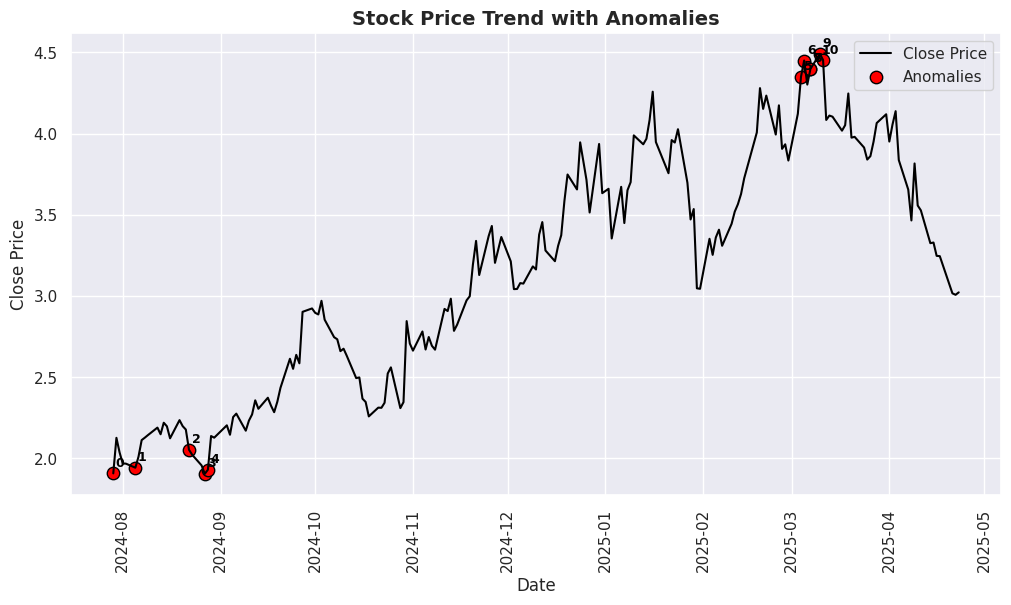

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="darkgrid")

# Create the plot
plt.figure(figsize=(12, 6))

# Plot Close Price trend
plt.plot(df_encoded["Date"], df_encoded["Close"], label="Close Price", color="black", linewidth=1.5)

# Plot anomalies as red scatter points
plt.scatter(
    anomaly_insights["Date"], anomaly_insights["Close"],
    color="red", label="Anomalies", marker="o", edgecolor="black", s=80
)

# Annotate anomalies with their index values
for i, (date, close, index) in enumerate(zip(anomaly_insights["Date"], anomaly_insights["Close"], anomaly_insights.index)):
    plt.annotate(str(index), (date, close), textcoords="offset points", xytext=(5, 5), ha='center', fontsize=9, color='black', fontweight='bold')

# Labels and title
plt.xlabel("Date", fontsize=12)
plt.ylabel("Close Price", fontsize=12)
plt.title("Stock Price Trend with Anomalies", fontsize=14, fontweight="bold")

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Show legend
plt.legend()

# Display the plot
plt.show()


Merging the URLs back again to analyze the articles labeled as anomalies

In [ ]:
import pandas as pd

# Merge anomaly insights with df_news to get URLs
anomaly_insights = anomaly_insights.merge(
    df_news[['Headline', 'URL']],  # Select only necessary columns
    left_on='Original_Headline',   # Matching anomalies to headlines
    right_on='Headline',
    how='left'  # Keep all anomalies even if no URL is found
)

# Drop the duplicate 'Headline' column from df_news
anomaly_insights.drop(columns=['Headline'], inplace=True)

# Display the updated dataframe
print(anomaly_insights.head())

        Date  Close  Sentiment_Score  Anomaly  \
0 2024-07-29  1.907           0.5574       -1   
1 2024-08-05  1.942           0.5574       -1   
2 2024-08-22  2.053           0.0056       -1   
3 2024-08-27  1.904           0.0056       -1   
4 2024-08-28  1.930           0.3612       -1   

                                   Original_Headline  \
0  What is the natural gas futures market? - U.S....   
1  What is the natural gas futures market? - U.S....   
2  US natural gas producers eye more output cuts ...   
3  US natural gas producers eye more output cuts ...   
4  Southern California natural gas market's unusu...   

                                                 URL  
0  https://news.google.com/rss/articles/CBMiY0FVX...  
1  https://news.google.com/rss/articles/CBMiY0FVX...  
2  https://news.google.com/rss/articles/CBMiswFBV...  
3  https://news.google.com/rss/articles/CBMiswFBV...  
4  https://news.google.com/rss/articles/CBMi-AFBV...  


In [ ]:
anomaly_insights

,Date,Close,Sentiment_Score,Anomaly,Original_Headline,URL
0,2024-07-29,1.907,0.5574,-1,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...
1,2024-08-05,1.942,0.5574,-1,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...
2,2024-08-22,2.053,0.0056,-1,US natural gas producers eye more output cuts ...,https://news.google.com/rss/articles/CBMiswFBV...
3,2024-08-27,1.904,0.0056,-1,US natural gas producers eye more output cuts ...,https://news.google.com/rss/articles/CBMiswFBV...
4,2024-08-28,1.930,0.3612,-1,Southern California natural gas market's unusu...,https://news.google.com/rss/articles/CBMi-AFBV...
5,2025-03-04,4.350,0.0000,-1,Europe's LNG summer buying binge puts market o...,https://news.google.com/rss/articles/CBMirwFBV...
6,2025-03-05,4.450,0.0000,-1,Europe's LNG summer buying binge puts market o...,https://news.google.com/rss/articles/CBMirwFBV...
7,2025-03-07,4.399,-0.2960,-1,"""Drill, Baby, Drill"" Natural Gas Producers Eye...",https://news.google.com/rss/articles/CBMingFBV...
8,2025-03-07,4.399,0.7717,-1,Nodal Exchange Achieves February Trading Recor...,https://news.google.com/rss/articles/CBMitAJBV...
9,2025-03-10,4.491,0.7717,-1,Nodal Exchange Achieves February Trading Recor...,https://news.google.com/rss/articles/CBMitAJBV...


USING NLP MODELS TO GAIN MORE DETAILED INSIGHTS

In [ ]:
!pip install lxml beautifulsoup4
!pip install newspaper3k


In [ ]:
!pip install lxml_html_clean newspaper3k


In [ ]:
import pandas as pd
import requests
from newspaper import Article
import spacy
from tqdm import tqdm

# Ensure tqdm is used with Pandas
tqdm.pandas()

# Load pre-trained NLP model
nlp = spacy.load("en_core_web_sm")

def extract_factors(text):
    """Extracts key factors (events, organizations, places) from text using spaCy."""
    doc = nlp(text)
    organizations = [ent.text for ent in doc.ents if ent.label_ in ["ORG", "GPE", "EVENT"]]
    return ", ".join(set(organizations))

def scrape_article(url):
    """Attempts to scrape article content from the given URL using newspaper3k."""
    try:
        article = Article(url)
        article.download()
        article.parse()
        return article.text
    except Exception as e:
        print(f"Failed to scrape {url}: {e}")
        return None

# Create a new DataFrame for extracted factors
factor_insights = []

# Ensure Trend data is mapped correctly
trend_mapping = df_encoded.set_index("Date")["Trend"].to_dict()

# **Use df_mapping to replace Trend values**
df_mapping = {0: "Neutral", 1: "Bullish", 2: "Bearish"}  # Ensure df_mapping is correct

# Iterate through anomaly_insights
for _, row in tqdm(anomaly_insights.iterrows(), total=len(anomaly_insights)):
    url = row["URL"]
    headline = row["Original_Headline"]
    sentiment_score = row["Sentiment_Score"]

    # Fetch Trend from df_encoded and map using df_mapping
    trend = trend_mapping.get(row["Date"], 0)  # Default to 0 (Neutral) if missing
    investor_sentiment = df_mapping.get(trend, "Neutral")  # Map Trend values

    article_text = scrape_article(url)

    if article_text:
        factors = extract_factors(article_text)
        confidence_score = 1.0  # High confidence if full article is used
    else:
        factors = extract_factors(headline)
        confidence_score = 0.5  # Lower confidence if only headline is used

    # Determine Market Sentiment based on Sentiment Score
    if sentiment_score > 0:
        market_sentiment = "Positive"
    elif sentiment_score < 0:
        market_sentiment = "Negative"
    else:
        market_sentiment = "Neutral"

    # Append the extracted insights
    factor_insights.append({
        "Date": row["Date"],
        "Original_Headline": headline,
        "URL": url,
        "Extracted_Factors": factors,
        "Confidence_Score": confidence_score,
        "Market_Sentiment": market_sentiment,
        "Investor_Sentiment": investor_sentiment  # **Now properly mapped**
    })

# Convert list to DataFrame
factor_insights_df = pd.DataFrame(factor_insights)

# Save to CSV
factor_insights_df.to_csv("factor_insights.csv", index=False)

print("Factor extraction completed and saved to factor_insights.csv.")


100%|██████████| 11/11 [00:02<00:00,  5.23it/s]

Factor extraction completed and saved to factor_insights.csv.


In [ ]:
factor_insights_df

,Date,Original_Headline,URL,Extracted_Factors,Confidence_Score,Market_Sentiment,Investor_Sentiment
0,2024-07-29,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,U.S. Energy Information Administration,0.5,Positive,Neutral
1,2024-08-05,What is the natural gas futures market? - U.S....,https://news.google.com/rss/articles/CBMiY0FVX...,U.S. Energy Information Administration,0.5,Positive,Neutral
2,2024-08-22,US natural gas producers eye more output cuts ...,https://news.google.com/rss/articles/CBMiswFBV...,"US, Reuters",0.5,Positive,Bullish
3,2024-08-27,US natural gas producers eye more output cuts ...,https://news.google.com/rss/articles/CBMiswFBV...,"US, Reuters",0.5,Positive,Bullish
4,2024-08-28,Southern California natural gas market's unusu...,https://news.google.com/rss/articles/CBMi-AFBV...,,0.5,Positive,Bullish
5,2025-03-04,Europe's LNG summer buying binge puts market o...,https://news.google.com/rss/articles/CBMirwFBV...,"LNG, Reuters",0.5,Neutral,Bullish
6,2025-03-05,Europe's LNG summer buying binge puts market o...,https://news.google.com/rss/articles/CBMirwFBV...,"LNG, Reuters",0.5,Neutral,Bullish
7,2025-03-07,"""Drill, Baby, Drill"" Natural Gas Producers Eye...",https://news.google.com/rss/articles/CBMingFBV...,,0.5,Negative,Bullish
8,2025-03-07,Nodal Exchange Achieves February Trading Recor...,https://news.google.com/rss/articles/CBMitAJBV...,"Power Achieves, Nodal Exchange Achieves",0.5,Positive,Bullish
9,2025-03-10,Nodal Exchange Achieves February Trading Recor...,https://news.google.com/rss/articles/CBMitAJBV...,"Power Achieves, Nodal Exchange Achieves",0.5,Positive,Bullish


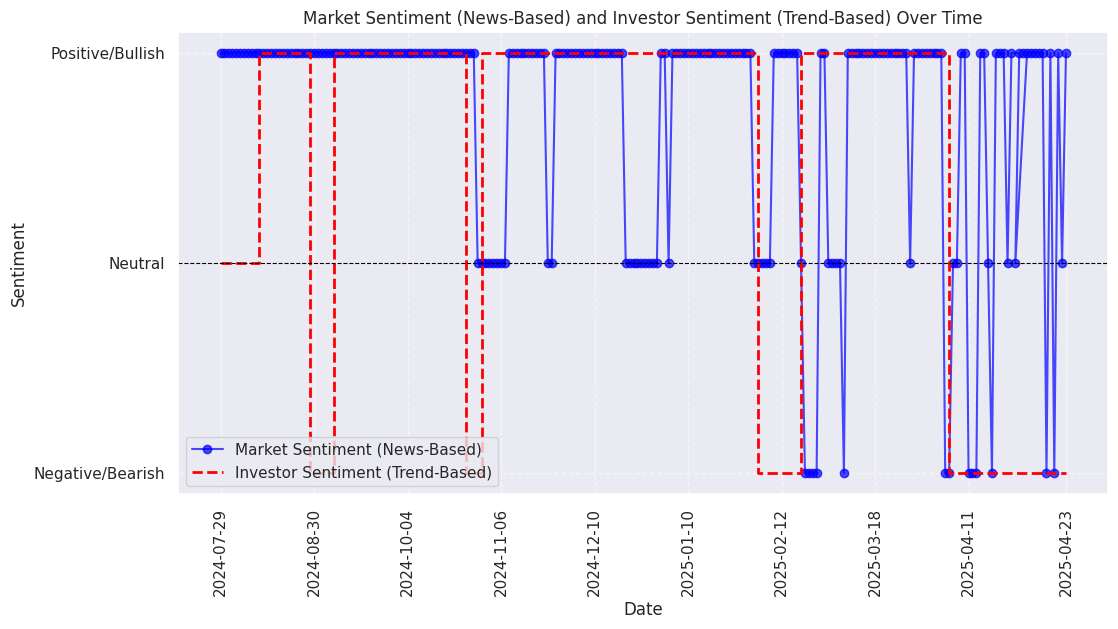

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure Date column is in datetime format
df_encoded["Date"] = pd.to_datetime(df_encoded["Date"])

# Sort by Date
df_encoded = df_encoded.sort_values(by="Date")

# Convert Sentiment_Score to sign-based values (-1, 0, 1)
df_encoded["Market_Sentiment_Plot"] = df_encoded["Sentiment_Score"].apply(lambda x: -1 if x < 0 else (1 if x > 0 else 0))

# Ensure Trend (Investor Sentiment) is properly mapped
df_mapping = {0: 0, 1: 1, 2: -1}  # Neutral: 0, Bullish: 1, Bearish: -1
df_encoded["Investor_Sentiment_Plot"] = df_encoded["Trend"].map(df_mapping)

# Define equal intervals for x-axis using index positions
num_ticks = 10  # Adjust for readability
tick_positions = np.linspace(0, len(df_encoded) - 1, num_ticks, dtype=int)
tick_labels = df_encoded.iloc[tick_positions]["Date"].dt.strftime("%Y-%m-%d")

# Create the figure
plt.figure(figsize=(12, 6))

# Plot Market Sentiment (continuous)
plt.plot(df_encoded.index, df_encoded["Market_Sentiment_Plot"], label="Market Sentiment (News-Based)", marker="o", linestyle="-", color="blue", alpha=0.7)

# Plot Investor Sentiment as a Step Plot
plt.step(df_encoded.index, df_encoded["Investor_Sentiment_Plot"], label="Investor Sentiment (Trend-Based)", color="red", linestyle="dashed", where="post", linewidth=2)

# Formatting the plot
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)  # Neutral reference line
plt.xlabel("Date")
plt.ylabel("Sentiment")
plt.title("Market Sentiment (News-Based) and Investor Sentiment (Trend-Based) Over Time")

# Set x-axis ticks at equal intervals using index positions
plt.xticks(tick_positions, tick_labels, rotation=90)

# Set y-axis labels
plt.yticks([-1, 0, 1], labels=["Negative/Bearish", "Neutral", "Positive/Bullish"])
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.6)

# Show the plot
plt.show()
